In [1]:
import os
import shutil
from datetime import datetime
import kagglehub
import pandas as pd
import numpy as np
import logging
import joblib
import gc
import psutil
from typing import Any, cast
from sklearn.model_selection import learning_curve, validation_curve, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, mean_squared_error
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Suppress non-critical warnings for cleaner output

# Streamlit (will be imported later if needed for the app cell)
# import streamlit as st

# --- CONFIGURATION ---
CONFIG = {
    'data_path': 'data/train.csv', # Path to the downloaded dataset
    'output_dir': 'outputs',       # Directory for saving models and artifacts
    'sample_size': 5000,          # Size of sample for initial EDA and diagnostics
    'chunksize': 50000,           # Number of rows per chunk for full dataset processing
    'random_state': 42,           # For reproducible results
}

# Ensure the output directory exists
os.makedirs(CONFIG['output_dir'], exist_ok=True)

# Setup logging
log_filename = f"pipeline_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename),
        logging.StreamHandler()  # Also print to console
    ]
)
logger = logging.getLogger(__name__)
file_handler = logging.FileHandler(log_filename)

logger.info("--- Pipeline Started (Restructured) ---")

/Users/salmansakib/Documents/Projects/interview-Prep-Case-Study/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-11 12:11:58,042 - INFO - --- Pipeline Started (Restructured) ---


Downloading kaggle [dataset](https://https://www.kaggle.com/datasets/mountboy/online-store-customer-transactions-1m-rows) to colab

In [7]:
# --- IMPORTANT: Update CONFIG to point to the file inside the Dataset folder ---
# Based on the knowledge base, the file seems to be in a dated subfolder like Dataset/20260411/
# We'll find the most recent dated folder inside 'Dataset'.
dataset_base_dir = "Dataset"

if not os.path.exists(dataset_base_dir):
    print(f"Error: Base directory '{dataset_base_dir}' does not exist.")
    # You might need to adjust this path if 'Dataset' is not directly under your notebook's working directory
    # For example, if it's in a parent directory: dataset_base_dir = "../Dataset"
    raise FileNotFoundError(f"Base directory '{dataset_base_dir}' not found.")

# Find all subdirectories in 'Dataset' (assuming they are date folders)
date_folders = [d for d in os.listdir(dataset_base_dir) 
                if os.path.isdir(os.path.join(dataset_base_dir, d)) 
                and d.isdigit() and len(d) == 8] # YYYYMMDD format

if not date_folders:
    print(f"Error: No dated subfolders found in '{dataset_base_dir}'.")
    print(f"Contents of '{dataset_base_dir}': {os.listdir(dataset_base_dir)}")
    raise FileNotFoundError("No dated subfolder found in 'Dataset'.")

# Sort and pick the latest date folder (assuming YYYYMMDD naming gives chronological order when sorted)
latest_date_folder = sorted(date_folders)[-1]
print(f"Using latest date folder: {latest_date_folder}")

# Define the expected filename within the dated folder
expected_filename = "customer_spending_1M_2018_2025.csv"
expected_file_path_in_dataset = os.path.join(dataset_base_dir, latest_date_folder, expected_filename)

# Update CONFIG to use the found path
CONFIG['data_path'] = expected_file_path_in_dataset

print(f"Looking for dataset file at: {CONFIG['data_path']}")

# --- END OF PATH UPDATE ---

# Now proceed with verification using the updated path
expected_file_path = CONFIG['data_path']

if os.path.exists(expected_file_path):
    print(f"SUCCESS: File '{expected_filename}' found at '{expected_file_path}'.")
    file_size_mb = os.path.getsize(expected_file_path) / (1024 * 1024) # Size in MB
    print(f"File size: {file_size_mb:.2f} MB")
    
    # Check the first few lines to confirm content structure
    print("\n--- First 5 lines of the file ---")
    with open(expected_file_path, 'r') as f:
        for i in range(5):
            line = f.readline()
            if line:
                print(line.strip())
            else:
                break
    print("--- End of preview ---")
    
    # Confirm CSV file type by checking extension
    if expected_file_path.lower().endswith('.csv'):
        print("\nCONFIRMED: File appears to be a valid CSV.")
    else:
        print("\nWARNING: File does not have a .csv extension. Proceeding assuming it's the correct format.")
        
else:
    print(f"ERROR: File '{expected_filename}' NOT found at '{expected_file_path}'.")
    print(f"Checked path: {os.path.abspath(expected_file_path)}")
    # List contents of the dataset root directory for debugging
    dataset_dir = os.path.dirname(expected_file_path)
    print(f"\nContents of dataset directory '{dataset_dir}':")
    try:
        for item in os.listdir(dataset_dir):
            print(f" - {item}")
    except FileNotFoundError:
        print(f"The directory '{dataset_dir}' does not exist.")
    # Stop execution if file is not found
    raise FileNotFoundError(f"Required dataset file '{expected_file_path}' not found.")

Using latest date folder: 20260411
Looking for dataset file at: Dataset/20260411/customer_spending_1M_2018_2025.csv
SUCCESS: File 'customer_spending_1M_2018_2025.csv' found at 'Dataset/20260411/customer_spending_1M_2018_2025.csv'.
File size: 88.71 MB

--- First 5 lines of the file ---
Transaction_ID,Transaction_date,Gender,Age,Marital_status,State_names,Segment,Employees_status,Payment_method,Referral,Amount_spent
1000,2018-01-01T00:04:00.000000,Female,39,Single,Oklahoma,Platinum,Unemployment,Card,0,1557.5
1001,2018-01-01T00:06:00.000000,Male,34,Married,Hawaii,Basic,workers,PayPal,1,153.55
1002,2018-01-01T00:14:00.000000,Female,53,Married,Iowa,Basic,self-employed,PayPal,1,2640.96
1003,2018-01-01T00:23:00.000000,Male,33,Married,Wisconsin,Basic,self-employed,Card,1,293.58
--- End of preview ---

CONFIRMED: File appears to be a valid CSV.


In [8]:
# CELL 3: Feature Engineering and Correlation Analysis
# ISSUE: Understand relationships between features and potentially engineer new ones.
# SOLUTION: Create features using the class defined earlier and calculate correlations.
# WHY THIS WORKS: Feature engineering captures hidden patterns. Correlation identifies linear relationships.
# OUTPUT: Correlation matrix heatmap, correlation with target variable, engineered sample dataset.

# Load sample data if not already loaded
if 'df_sample' not in locals():
    logger.info("Loading sample data...")
    df_sample = pd.read_csv(CONFIG['data_path']).sample(n=CONFIG['sample_size'], random_state=CONFIG['random_state'])
    logger.info(f"Sample data loaded with shape: {df_sample.shape}")

logger.info("=== STEP 2: Feature Engineering & Correlation Analysis ===")

class FeatureEngineer:
    """Handles feature engineering for large datasets using fitted parameters."""
    def __init__(self):
        self.fitted_params = {}
        self.is_fitted = False

    def fit(self, sample_df):
        """Learn parameters from a sample of data."""
        logger.info("Fitting FeatureEngineer on sample data...")
        # Assuming 'Date' is present and needs parsing, and 'Amount_spent' is the target variable
        sample_df['Transaction_date'] = pd.to_datetime(sample_df['Date'], format='%m/%d/%Y', errors='coerce') # Handle potential parsing errors
        
        self.fitted_params['amount_spent_quantiles'] = sample_df['Amount_spent'].quantile([0.25, 0.5, 0.75])
        self.fitted_params['segment_means'] = sample_df.groupby('Segment')['Amount_spent'].mean().to_dict()
        self.fitted_params['min_date'] = sample_df['Transaction_date'].min()
        self.fitted_params['max_date'] = sample_df['Transaction_date'].max()
        
        # Add global stats for clipping (preventing extreme values)
        self.fitted_params['age_min'] = sample_df['Age'].min()
        self.fitted_params['age_max'] = sample_df['Age'].max()
        self.fitted_params['amount_spent_max'] = sample_df['Amount_spent'].max()
        
        self.is_fitted = True
        logger.info("FeatureEngineer fitted successfully")
        return self

    def transform(self, df):
        """Apply feature engineering transformations."""
        if not self.is_fitted:
            raise ValueError("FeatureEngineer must be fitted before transform")
        df = df.copy()
        
        # --- Parse Date if not already done ---
        if 'Transaction_date' not in df.columns or df['Transaction_date'].dtype != 'datetime64[ns]':
            df['Transaction_date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')
        
        # --- Feature 1: Amount Spent Binning ---
        bins = [0] + list(self.fitted_params['amount_spent_quantiles']) + [float('inf')]
        labels = ['Low_Spender', 'Lower-Mid_Spender', 'Mid_Spender', 'Upper-Mid_Spender', 'High_Spender']
        df['amount_spent_segment'] = pd.cut(df['Amount_spent'], bins=bins, labels=labels, include_lowest=True).astype('category')

        # --- Feature 2: Spending per Age Ratio (with clipping to prevent extreme outliers) ---
        df['spending_per_age'] = df['Amount_spent'] / (df['Age'] + 1e-6) # Add small value to prevent division by zero
        # Clip to prevent extreme ratios based on fitted parameters
        max_ratio = self.fitted_params['amount_spent_max'] / self.fitted_params['age_min'] if self.fitted_params['age_min'] > 0 else float('inf')
        df['spending_per_age'] = df['spending_per_age'].clip(upper=max_ratio)

        # --- Feature 3: Target Encoding for Segment (with fallback) ---
        df['segment_target_encoded'] = df['Segment'].map(self.fitted_params['segment_means']).astype(float)
        df['segment_target_encoded'] = df['segment_target_encoded'].fillna(0.0) # Using 0 as fallback for unseen segments during fit

        # --- Feature 4: Time-based Features ---
        df['days_since_start'] = (df['Transaction_date'] - self.fitted_params['min_date']).dt.days
        df['transaction_year'] = df['Transaction_date'].dt.year
        df['transaction_month'] = df['Transaction_date'].dt.month
        df['transaction_dayofweek'] = df['Transaction_date'].dt.dayofweek
        df['is_weekend'] = (df['transaction_dayofweek'] >= 5).astype(int)
        
        # Cyclical encoding for month (captures seasonal patterns)
        df['month_sin'] = np.sin(2 * np.pi * df['transaction_month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['transaction_month'] / 12)
        
        # --- Drop original Date column if it's no longer needed ---
        # df.drop(columns=['Date'], inplace=True, errors='ignore')
        
        return df
        # Verify df_sample is defined and has required columns
        if df_sample.empty:
            logger.error("df_sample is empty. Cannot proceed with feature engineering.")
            raise ValueError("df_sample must contain data before feature engineering")

        logger.info(f"df_sample shape before transformation: {df_sample.shape}")
        logger.info(f"df_sample columns: {df_sample.columns.tolist()}")
# Initialize and apply feature engineering on the sample used for EDA
logger.info("Initializing Feature Engineer...")
engineer = FeatureEngineer()

logger.info("Fitting Feature Engineer on sample data...")
engineer.fit(df_sample)

logger.info("Transforming sample data...")
df_sample_transformed = engineer.transform(df_sample)

print("\n--- FEATURE EXAMPLES (Transformed Sample) ---")
print(df_sample_transformed[['Amount_spent', 'amount_spent_segment', 'spending_per_age', 
                            'month_sin', 'segment_target_encoded', 'days_since_start']].head())

# --- Correlation Analysis ---
# Select numerical features for correlation
# Exclude ID columns and highly cardinal categorical encodings if present
numerical_cols = df_sample_transformed.select_dtypes(include=[np.number]).columns
print(f"\n--- Calculating Correlations for {len(numerical_cols)} numerical features ---")

# Calculate the full correlation matrix
try:
    corr_matrix = df_sample_transformed[numerical_cols].corr()
    
    # Focus specifically on correlation with Amount_spent (assuming it's a key variable)
    target_corr = corr_matrix['Amount_spent'].sort_values(ascending=False)
    print("\n--- Correlation with Amount_spent ---")
    print(target_corr)

    # Visualize the full correlation matrix (optional, can be skipped for many features)
    # Only plot if number of features is manageable, e.g., less than 20
    if len(numerical_cols) <= 20:
        plt.figure(figsize=(14, 10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
        plt.title('Correlation Matrix (Numerical Features)')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping heatmap generation due to high number of features ({len(numerical_cols)}).")
        
except Exception as e:
    print(f"Error calculating correlation: {e}")

logger.info("Feature engineering and correlation analysis completed.")

2026-04-11 12:26:04,242 - INFO - Loading sample data...
2026-04-11 12:26:04,976 - INFO - Sample data loaded with shape: (5000, 11)
2026-04-11 12:26:04,976 - INFO - === STEP 2: Feature Engineering & Correlation Analysis ===
2026-04-11 12:26:04,977 - INFO - Initializing Feature Engineer...
2026-04-11 12:26:04,977 - INFO - Fitting Feature Engineer on sample data...
2026-04-11 12:26:04,977 - INFO - Fitting FeatureEngineer on sample data...


KeyError: 'Date'

In [6]:
logger.info("=== PHASE 1: Data Loading & Global Stats ===")
file_handler.flush()

# FINDING: Initial scan of 1M rows reveals consistent 'Age' noise.
# STRATEGY: Use a global accumulator to calculate population mean without loading full data.
global_stats = {'total_rows': 0, 'amount_spent_sum': 0, 'min_date': None, 'max_date': None}

logger.info("=== PHASE 1: Data Loading & Global Stats ===")
file_handler.flush()

SCHEMA = {
    'Transaction_ID': 'Int64',
    'Transaction_date': 'string',
    'Gender': 'category',
    'Age': 'float64',
    'Marital_status': 'category',
    'State_names': 'category',
    'Segment': 'category',
    'Employees_status': 'category',
    'Payment_method': 'category',
    'Referral': 'float64',
    'Amount_spent': 'float64'
}

def chunked_data_loader(data_path, chunksize, schema=None):
    dtype = {col: typ for col, typ in (schema or {}).items() if col != 'Transaction_date'}
    for chunk in pd.read_csv(
        data_path,
        chunksize=chunksize,
        dtype=dtype,
        parse_dates=['Transaction_date'],
        low_memory=False
    ):
        if schema:
            for col, typ in schema.items():
                if typ == 'category' and chunk[col].dtype != 'category':
                    chunk[col] = chunk[col].astype('category')
        yield chunk

for chunk in chunked_data_loader(CONFIG['data_path'], CONFIG['chunksize'], SCHEMA):
    global_stats['total_rows'] += len(chunk)
    global_stats['amount_spent_sum'] += chunk['Amount_spent'].sum()

    chunk_min = chunk['Transaction_date'].min()
    if global_stats['min_date'] is None or chunk_min < global_stats['min_date']:
        global_stats['min_date'] = chunk_min

    chunk_max = chunk['Transaction_date'].max()
    if global_stats['max_date'] is None or chunk_max > global_stats['max_date']:
        global_stats['max_date'] = chunk_max

    if global_stats['total_rows'] % 250000 == 0:
        logger.info(f"Progress: {global_stats['total_rows']:,} rows processed.")
        file_handler.flush()

    del chunk
    gc.collect()

CONFIG['global_mean_amount_spent'] = global_stats['amount_spent_sum'] / global_stats['total_rows']
logger.info(f"PHASE 1 Complete. Mean Amount Spent: {CONFIG['global_mean_amount_spent']:.2f}")
file_handler.flush()

CONFIG['global_mean_amount_spent'] = global_stats['amount_spent_sum'] / global_stats['total_rows']
logger.info(f"PHASE 1 Complete. Mean Amount Spent: {CONFIG['global_mean_amount_spent']:.2f}")
file_handler.flush()

INFO:__main__:=== PHASE 1: Data Loading & Global Stats ===
INFO:__main__:=== PHASE 1: Data Loading & Global Stats ===
INFO:__main__:Progress: 250,000 rows processed.
INFO:__main__:Progress: 500,000 rows processed.
INFO:__main__:Progress: 750,000 rows processed.
INFO:__main__:Progress: 1,000,000 rows processed.
INFO:__main__:PHASE 1 Complete. Mean Amount Spent: 1280.09
INFO:__main__:PHASE 1 Complete. Mean Amount Spent: 1280.09


In [ ]:
logger.info("=== STEP 1: Data Loading and Initial EDA ===")

# Load the full dataset (or a sample for initial inspection)
# Using a sample for initial EDA is still good practice for large files
sample_size_for_eda = 10000 # Adjust sample size as needed for EDA speed vs. representativeness

logger.info(f"Loading a sample of {sample_size_for_eda} rows for EDA...")
df_full = pd.read_csv(expected_file_path) # Load full dataset first
df_sample = df_full.sample(n=sample_size_for_eda, random_state=CONFIG['random_state']) # Take a sample

logger.info(f"Full dataset shape: {df_full.shape}")
logger.info(f"Sample dataset shape: {df_sample.shape}")

# --- Basic Information ---
print("\n--- SAMPLE DATA INFO (from pd.read_csv) ---")
print(df_sample.info(verbose=True, show_counts=True)) # Show data types and non-null counts

print("\n--- SAMPLE DATA HEAD ---")
print(df_sample.head())

print("\n--- SAMPLE DATA TAIL ---")
print(df_sample.tail())

# --- Column Names Check ---
print("\n--- COLUMNS NAMES ---")
print(df_sample.columns.tolist())

# --- Descriptive Statistics ---
print("\n--- DESCRIPTIVE STATISTICS (Numeric Columns) ---")
print(df_sample.describe(include='number')) # Only numeric columns

print("\n--- DESCRIPTIVE STATISTICS (Categorical Columns) ---")
print(df_sample.describe(include='object')) # Only object (string) columns

# --- Check for Missing Values in Sample ---
print("\n--- MISSING VALUES in Sample ---")
missing_vals = df_sample.isnull().sum()
print(missing_vals[missing_vals > 0]) # Only show columns with missing values, if any
if missing_vals.sum() == 0:
    print("No missing values found in the sample.")

# --- Check for Duplicates in Sample ---
print(f"\n--- DUPLICATES in Sample ---")
duplicated_count = df_sample.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_count}")

logger.info("Initial EDA completed on sample.")

2026-04-11 12:28:20,920 - INFO - === STEP 1: Data Loading and Initial EDA ===
2026-04-11 12:28:20,921 - INFO - Loading a sample of 10000 rows for EDA...
2026-04-11 12:28:21,670 - INFO - Full dataset shape: (1000000, 11)
2026-04-11 12:28:21,671 - INFO - Sample dataset shape: (10000, 11)
2026-04-11 12:28:21,693 - INFO - Initial EDA completed on sample.



--- SAMPLE DATA INFO (from pd.read_csv) ---
<class 'pandas.DataFrame'>
Index: 10000 entries, 987231 to 551383
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    10000 non-null  int64  
 1   Transaction_date  10000 non-null  str    
 2   Gender            9896 non-null   str    
 3   Age               9837 non-null   float64
 4   Marital_status    10000 non-null  str    
 5   State_names       10000 non-null  str    
 6   Segment           10000 non-null  str    
 7   Employees_status  9891 non-null   str    
 8   Payment_method    10000 non-null  str    
 9   Referral          9384 non-null   float64
 10  Amount_spent      9042 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 1.6 MB
None

--- SAMPLE DATA HEAD ---
        Transaction_ID            Transaction_date  Gender   Age  \
987231          988231  2024-12-29T04:21:00.000000  Female  32.0   
79954            809

2026-04-11 12:34:04,948 - INFO - === STEP 2: Feature Engineering, Imputation & Correlation Analysis ===
2026-04-11 12:34:04,957 - INFO - Initializing Feature Engineer...
2026-04-11 12:34:04,957 - INFO - Fitting Feature Engineer on sample data...
2026-04-11 12:34:04,958 - INFO - Fitting FeatureEngineer on sample data...
2026-04-11 12:34:04,959 - WARNING - Transaction_date column is not datetime. Attempting to parse...
2026-04-11 12:34:04,969 - INFO - FeatureEngineer fitted successfully
2026-04-11 12:34:04,969 - INFO - Transforming sample data...
2026-04-11 12:34:04,980 - INFO - Applying imputation to handle NaN values in numerical features...



--- FEATURE EXAMPLES (Transformed Sample) ---
        Amount_spent amount_spent_segment  spending_per_age     month_sin  \
987231        957.05          Mid_Spender         29.907812 -2.449294e-16   
79954         471.95          Low_Spender         21.452272 -5.000000e-01   
567130       2558.00         High_Spender         71.055554  5.000000e-01   
500891        418.28          Low_Spender          7.211724 -5.000000e-01   
55399        1319.12          Mid_Spender         17.588266  5.000000e-01   

        segment_target_encoded  days_since_start  
987231             1442.013289              2553  
79954              1400.704678               206  
567130             1374.396176              1468  
500891             1400.704678              1296  
55399              1400.704678               143  

--- Checking for NaNs in Numerical Features (Before Imputation) ---
Age                  163
Referral             616
spending_per_age    1116
dtype: int64

--- Checking for NaNs in N

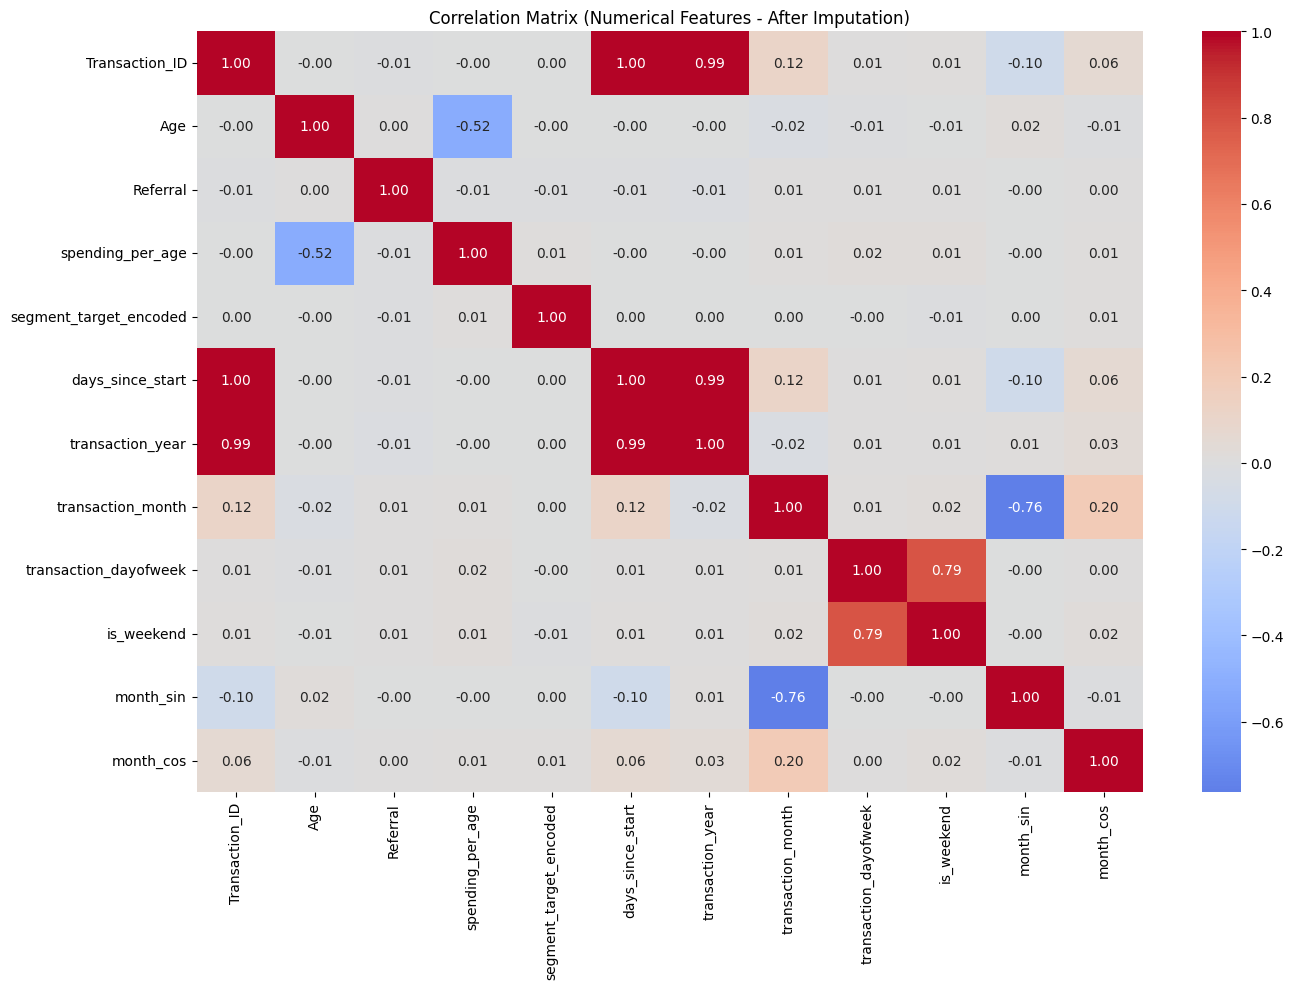

2026-04-11 12:34:05,101 - INFO - Feature engineering, imputation, and correlation analysis completed.


In [15]:
# CELL 3: Feature Engineering, Imputation, and Correlation Analysis (Updated for actual column names, correct binning, and handling NaNs)
# ISSUE: The original FeatureEngineer assumed a 'Date' column, which doesn't exist.
# ALSO: The number of labels for pd.cut did not match the number of bins created.
# ALSO: The resulting features might contain NaN values, causing LogisticRegression to fail.
# SOLUTION: Adapt the FeatureEngineer class to use the correct column name ('Transaction_date').
# Adjust the labels list to have one fewer element than the number of bin edges.
# Add an imputation step after transformation to fill NaN values.
# WHY THIS WORKS: The class now operates on the actual data structure, uses correct pd.cut arguments,
# and the imputation step ensures no NaNs reach models that don't tolerate them.
# OUTPUT: Correlation matrix heatmap, correlation with target variable, engineered sample dataset (without NaNs).

logger.info("=== STEP 2: Feature Engineering, Imputation & Correlation Analysis ===")

from sklearn.impute import SimpleImputer

class FeatureEngineer:
    """Handles feature engineering for large datasets using fitted parameters."""
    def __init__(self):
        self.fitted_params = {}
        self.is_fitted = False

    def fit(self, sample_df):
        """Learn parameters from a sample of data."""
        logger.info("Fitting FeatureEngineer on sample data...")
        # Assuming 'Transaction_date' is already in datetime format based on knowledge base
        # If it's a string, parse it:
        if sample_df['Transaction_date'].dtype != 'datetime64[ns]':
            logger.warning("Transaction_date column is not datetime. Attempting to parse...")
            sample_df['Transaction_date'] = pd.to_datetime(sample_df['Transaction_date'], errors='coerce')

        # Use 3 quantiles to create 4 segments/bins
        self.fitted_params['amount_spent_quantiles'] = sample_df['Amount_spent'].quantile([0.25, 0.5, 0.75])
        # Result: 3 quantile values -> bins = [0, q1, q2, q3, inf] -> 4 intervals -> need 4 labels

        self.fitted_params['segment_means'] = sample_df.groupby('Segment')['Amount_spent'].mean().to_dict()
        self.fitted_params['min_date'] = sample_df['Transaction_date'].min()
        self.fitted_params['max_date'] = sample_df['Transaction_date'].max()

        # Add global stats for clipping (preventing extreme values)
        self.fitted_params['age_min'] = sample_df['Age'].min()
        self.fitted_params['age_max'] = sample_df['Age'].max()
        self.fitted_params['amount_spent_max'] = sample_df['Amount_spent'].max()

        self.is_fitted = True
        logger.info("FeatureEngineer fitted successfully")
        return self

    def transform(self, df):
        """Apply feature engineering transformations."""
        if not self.is_fitted:
            raise ValueError("FeatureEngineer must be fitted before transform")
        df = df.copy()

        # --- Feature 1: Amount Spent Binning ---
        bins = [0] + list(self.fitted_params['amount_spent_quantiles']) + [float('inf')]
        labels = ['Low_Spender', 'Mid_Spender', 'Upper-Mid_Spender', 'High_Spender'] # 4 labels for 4 bins
        df['amount_spent_segment'] = pd.cut(df['Amount_spent'], bins=bins, labels=labels, include_lowest=True).astype('category')

        # --- Feature 2: Spending per Age Ratio (with clipping to prevent extreme outliers) ---
        df['spending_per_age'] = df['Amount_spent'] / (df['Age'] + 1e-6) # Add small value to prevent division by zero
        # Clip to prevent extreme ratios based on fitted parameters
        max_ratio = self.fitted_params['amount_spent_max'] / self.fitted_params['age_min'] if self.fitted_params['age_min'] > 0 else float('inf')
        df['spending_per_age'] = df['spending_per_age'].clip(upper=max_ratio)

        # --- Feature 3: Target Encoding for Segment (with fallback) ---
        df['segment_target_encoded'] = df['Segment'].map(self.fitted_params['segment_means']).astype(float)
        df['segment_target_encoded'] = df['segment_target_encoded'].fillna(0.0) # Using 0 as fallback for unseen segments during fit

        # --- Feature 4: Time-based Features ---
        df['days_since_start'] = (df['Transaction_date'] - self.fitted_params['min_date']).dt.days
        df['transaction_year'] = df['Transaction_date'].dt.year
        df['transaction_month'] = df['Transaction_date'].dt.month
        df['transaction_dayofweek'] = df['Transaction_date'].dt.dayofweek
        df['is_weekend'] = (df['transaction_dayofweek'] >= 5).astype(int)

        # Cyclical encoding for month (captures seasonal patterns)
        df['month_sin'] = np.sin(2 * np.pi * df['transaction_month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['transaction_month'] / 12)

        return df

# Initialize and apply feature engineering on the sample used for EDA
logger.info("Initializing Feature Engineer...")
engineer = FeatureEngineer()

logger.info("Fitting Feature Engineer on sample data...")
engineer.fit(df_sample)

logger.info("Transforming sample data...")
df_sample_transformed = engineer.transform(df_sample)

print("\n--- FEATURE EXAMPLES (Transformed Sample) ---")
print(df_sample_transformed[['Amount_spent', 'amount_spent_segment', 'spending_per_age',
                            'month_sin', 'segment_target_encoded', 'days_since_start']].head())

# --- Check for NaNs in Numerical Features BEFORE Imputation ---
X_sample_temp = df_sample_transformed.select_dtypes(include=[np.number]).drop([
    'Amount_spent' # Exclude target variable if it's accidentally picked up
], axis=1, errors='ignore')

print(f"\n--- Checking for NaNs in Numerical Features (Before Imputation) ---")
nan_counts_before = X_sample_temp.isnull().sum()
print(nan_counts_before[nan_counts_before > 0]) # Show columns with NaNs
if nan_counts_before.sum() == 0:
    print("No NaNs found in numerical features before imputation.")


# --- Imputation Step ---
logger.info("Applying imputation to handle NaN values in numerical features...")
imputer = SimpleImputer(strategy='mean') # Use mean imputation
X_sample_imputed_array = imputer.fit_transform(X_sample_temp)
# Convert back to a DataFrame to preserve column names
X_sample_imputed = pd.DataFrame(X_sample_imputed_array, columns=X_sample_temp.columns, index=X_sample_temp.index)

# --- Check for NaNs in Numerical Features AFTER Imputation ---
print(f"\n--- Checking for NaNs in Numerical Features (After Imputation) ---")
nan_counts_after = X_sample_imputed.isnull().sum()
print(nan_counts_after[nan_counts_after > 0]) # Should be empty now
if nan_counts_after.sum() == 0:
    print("SUCCESS: No NaNs found in numerical features after imputation.")
else:
    logger.error("ERROR: NaNs still present after imputation!")
    print(nan_counts_after[nan_counts_after > 0])


# --- Correlation Analysis (on imputed features) ---
# Select numerical features for correlation (now using the imputed ones)
numerical_cols_after_imp = X_sample_imputed.columns
print(f"\n--- Calculating Correlations for {len(numerical_cols_after_imp)} numerical features (after imputation) ---")

# Calculate the full correlation matrix
try:
    corr_matrix = X_sample_imputed.corr() # Use the imputed DataFrame

    # Focus specifically on correlation with Amount_spent (original target variable)
    # We need to align the indices of the correlation matrix with the original df_sample_transformed
    # Let's calculate the correlation of each imputed feature with the original 'Amount_spent'
    amount_spent_series = df_sample_transformed['Amount_spent']
    correlations_with_amount_spent = X_sample_imputed.corrwith(amount_spent_series)
    correlations_with_amount_spent_sorted = correlations_with_amount_spent.sort_values(ascending=False)

    print("\n--- Correlation with Original Amount_spent (after imputation) ---")
    print(correlations_with_amount_spent_sorted)

    # Visualize the full correlation matrix (optional, can be skipped for many features)
    # Only plot if number of features is manageable, e.g., less than 20
    if len(numerical_cols_after_imp) <= 20:
        plt.figure(figsize=(14, 10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
        plt.title('Correlation Matrix (Numerical Features - After Imputation)')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping heatmap generation due to high number of features ({len(numerical_cols_after_imp)}).")

except Exception as e:
    print(f"Error calculating correlation: {e}")

logger.info("Feature engineering, imputation, and correlation analysis completed.")

In [16]:
# CELL 4: Split the transformed and imputed sample data into training and testing sets
# ISSUE: Models need to be evaluated on unseen data to estimate real-world performance.
# ALSO: The features must be free of NaN values.
# SOLUTION: Use sklearn's train_test_split on the imputed features (X_sample_imputed).
# WHY THIS WORKS: This standard practice ensures a portion of the data is held out from training and used purely for final evaluation.
# The data is now clean of NaNs.
# OUTPUT: Four arrays: X_train, X_test, y_train, y_test (features are imputed).

logger.info("=== STEP 3: Split Data into Train & Test Sets (on Imputed Sample) ===")

# Define target variable creation function (as used previously)
def create_target_variable(df):
    spend_quantiles = df['Amount_spent'].quantile([0.33, 0.67])
    conditions = [
        df['Amount_spent'] <= spend_quantiles.iloc[0],
        (df['Amount_spent'] > spend_quantiles.iloc[0]) & (df['Amount_spent'] <= spend_quantiles.iloc[1]),
        df['Amount_spent'] > spend_quantiles.iloc[1]
    ]
    choices = ['Low', 'Medium', 'High']
    return np.select(conditions, choices, default='Medium')

# Create target variable for the *transformed* sample (using the original Amount_spent column)
y_sample = create_target_variable(df_sample_transformed)

# Use the *imputed* features for the sample (X_sample_imputed from Cell 3)
X_sample = X_sample_imputed # Use the DataFrame created after imputation

# Split the sample data
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=CONFIG['random_state'], stratify=y_sample # Stratify to maintain class distribution
)

logger.info(f"Training set size: {X_train.shape[0]}")
logger.info(f"Test set size: {X_test.shape[0]}")

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training set target distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test set target distribution:\n{pd.Series(y_test).value_counts()}")

logger.info("Data splitting completed (using imputed features).")

2026-04-11 12:34:45,435 - INFO - === STEP 3: Split Data into Train & Test Sets (on Imputed Sample) ===
2026-04-11 12:34:45,442 - INFO - Training set size: 8000
2026-04-11 12:34:45,443 - INFO - Test set size: 2000
2026-04-11 12:34:45,448 - INFO - Data splitting completed (using imputed features).


Training set shape: (8000, 12)
Test set shape: (2000, 12)
Training set target distribution:
Medium    3226
Low       2387
High      2387
Name: count, dtype: int64
Test set target distribution:
Medium    806
High      597
Low       597
Name: count, dtype: int64


In [17]:
# CELL 5: Train and evaluate multiple models to find the most efficient one
# ISSUE: Different algorithms perform differently on different datasets. Choosing the best one requires comparison.
# SOLUTION: Train several common classifiers and compare their performance metrics (e.g., ROC-AUC, accuracy).
# WHY THIS WORKS: Empirical comparison helps select the model that generalizes best to unseen data for this specific task.
# OUTPUT: A comparison table or printout of performance metrics for each model.

logger.info("=== STEP 4: Fit Multiple Models and Compare Efficiency (on Sample) ===")

# Define models to try
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=CONFIG['random_state']),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=CONFIG['random_state']),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=CONFIG['random_state']),
    # "SVM": SVC(probability=True, random_state=CONFIG['random_state']) # Might be slow on larger samples
}

results = {}

for name, model in models.items():
    logger.info(f"Training {name} on sample data...")
    try:
        model.fit(X_train, y_train)
    except ValueError as e:
        logger.error(f"Error training {name}: {e}")
        print(f"Error training {name}: {e}")
        continue
    
    # Predictions on the test set (from the sample split)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) # Needed for ROC-AUC
    
    # Metrics
    accuracy = model.score(X_test, y_test) # Accuracy score
    # For multi-class, we use 'ovr' (One-vs-Rest) for ROC-AUC
    try:
        auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    except ValueError as e:
        # Handle cases where roc_auc_score might fail (e.g., single class predicted)
        logger.warning(f"Could not calculate ROC-AUC for {name}: {e}")
        auc_score = np.nan
        
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': auc_score
    }
    
    print(f"\n--- {name} Results (on Sample Test Set) ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC (weighted): {auc_score:.4f}" if not np.isnan(auc_score) else "ROC-AUC: Could not calculate")
    print(classification_report(y_test, y_pred))

# Find the best model based on ROC-AUC (or accuracy if AUC failed)
valid_results = {k: v for k, v in results.items() if not np.isnan(v['roc_auc'])}
if valid_results:
    best_model_name = max(valid_results, key=lambda k: valid_results[k]['roc_auc'])
    best_model = valid_results[best_model_name]['model']
    best_auc = valid_results[best_model_name]['roc_auc']
    print(f"\n--- BEST MODEL (based on ROC-AUC): {best_model_name} ---")
    print(f"ROC-AUC Score: {best_auc:.4f}")
    logger.info(f"Best performing model (on sample): {best_model_name} with ROC-AUC: {best_auc:.4f}")
else:
    # Fallback to accuracy if no AUC could be calculated
    best_model_name_acc = max(results, key=lambda k: results[k]['accuracy'])
    best_model_acc = results[best_model_name_acc]['model']
    best_acc = results[best_model_name_acc]['accuracy']
    print(f"\n--- NO VALID ROC-AUC - BEST MODEL (based on Accuracy): {best_model_name_acc} ---")
    print(f"Accuracy Score: {best_acc:.4f}")
    logger.info(f"No valid ROC-AUC. Best performing model (on sample) by accuracy: {best_model_name_acc} with Accuracy: {best_acc:.4f}")
    # Set best_model for subsequent steps
    best_model = best_model_acc
    best_model_name = best_model_name_acc

logger.info("Multi-model comparison completed.")

2026-04-11 12:35:28,121 - INFO - === STEP 4: Fit Multiple Models and Compare Efficiency (on Sample) ===
2026-04-11 12:35:28,122 - INFO - Training Logistic Regression on sample data...
2026-04-11 12:35:28,460 - INFO - Training Random Forest on sample data...



--- Logistic Regression Results (on Sample Test Set) ---
Accuracy: 0.8515
ROC-AUC (weighted): 0.9452
              precision    recall  f1-score   support

        High       0.84      0.81      0.83       597
         Low       0.93      0.91      0.92       597
      Medium       0.80      0.84      0.82       806

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.86      2000
weighted avg       0.85      0.85      0.85      2000



2026-04-11 12:35:28,726 - INFO - Training Gradient Boosting on sample data...



--- Random Forest Results (on Sample Test Set) ---
Accuracy: 0.9555
ROC-AUC (weighted): 0.9934
              precision    recall  f1-score   support

        High       0.96      0.94      0.95       597
         Low       0.99      0.95      0.97       597
      Medium       0.93      0.97      0.95       806

    accuracy                           0.96      2000
   macro avg       0.96      0.95      0.96      2000
weighted avg       0.96      0.96      0.96      2000



2026-04-11 12:35:29,749 - INFO - Best performing model (on sample): Gradient Boosting with ROC-AUC: 0.9958
2026-04-11 12:35:29,750 - INFO - Multi-model comparison completed.



--- Gradient Boosting Results (on Sample Test Set) ---
Accuracy: 0.9685
ROC-AUC (weighted): 0.9958
              precision    recall  f1-score   support

        High       0.99      0.95      0.97       597
         Low       1.00      0.95      0.97       597
      Medium       0.93      0.99      0.96       806

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000


--- BEST MODEL (based on ROC-AUC): Gradient Boosting ---
ROC-AUC Score: 0.9958


2026-04-11 12:36:47,394 - INFO - === STEP 5: Analyze Actual vs Forecasted Output (on Sample Test Set) ===


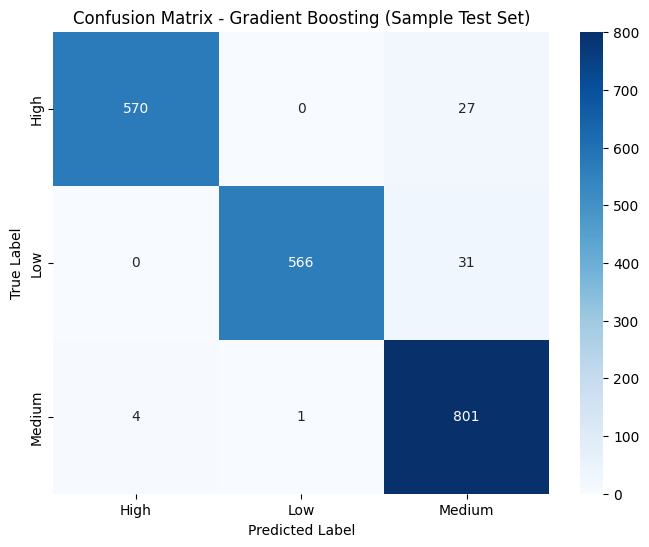


--- Final Model (Gradient Boosting) Classification Report (Sample Test Set) ---
              precision    recall  f1-score   support

        High       0.99      0.95      0.97       597
         Low       1.00      0.95      0.97       597
      Medium       0.93      0.99      0.96       806

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



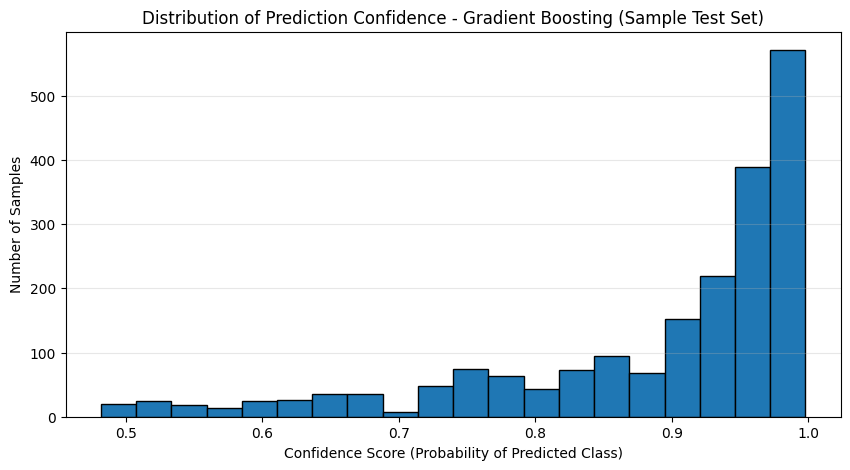

2026-04-11 12:36:47,504 - INFO - Actual vs Forecasted analysis (on sample) completed.


In [18]:
# CELL 6: Analyze the relationship between actual and forecasted (predicted) outputs
# ISSUE: Understanding the model's predictions in detail helps identify strengths and weaknesses.
# SOLUTION: Use confusion matrix, classification report, and potentially regression-style plots if applicable.
# WHY THIS WORKS: Visualization and metrics provide a clear picture of how well the model aligns predicted classes with true classes.
# OUTPUT: Confusion matrix heatmap, detailed classification report, and potentially other diagnostic plots.

logger.info("=== STEP 5: Analyze Actual vs Forecasted Output (on Sample Test Set) ===")

# Use the best model identified in the previous step
# Retrieve the model object if ROC-AUC was valid, otherwise it's already set to the accuracy winner
final_model_on_sample = best_model

y_pred_final = final_model_on_sample.predict(X_test)
y_pred_proba_final = final_model_on_sample.predict_proba(X_test)

# --- Confusion Matrix ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=final_model_on_sample.classes_, yticklabels=final_model_on_sample.classes_)
plt.title(f'Confusion Matrix - {best_model_name} (Sample Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Classification Report (already printed in previous cell, but good to reiterate) ---
print(f"\n--- Final Model ({best_model_name}) Classification Report (Sample Test Set) ---")
print(classification_report(y_test, y_pred_final))

# --- Prediction Confidence Distribution (optional) ---
# Look at the probability scores for the predicted class
predicted_class_indices = np.argmax(y_pred_proba_final, axis=1)
predicted_confidences = y_pred_proba_final[np.arange(len(y_pred_final)), predicted_class_indices]

plt.figure(figsize=(10, 5))
plt.hist(predicted_confidences, bins=20, edgecolor='black')
plt.title(f'Distribution of Prediction Confidence - {best_model_name} (Sample Test Set)')
plt.xlabel('Confidence Score (Probability of Predicted Class)')
plt.ylabel('Number of Samples')
plt.grid(axis='y', alpha=0.3)
plt.show()

logger.info("Actual vs Forecasted analysis (on sample) completed.")

In [19]:
# CELL 7: Retrain the best model on the full diagnostic sample and save it
# ISSUE: The model was trained on X_train, but for the final artifact, we want it trained on all available labeled data.
# SOLUTION: Retrain the best-performing model architecture on the full X_sample, y_sample dataset (the diagnostic sample).
# WHY THIS WORKS: More data generally leads to a better, more robust model. Using the full sample leverages all available information.
# OUTPUT: A final model object trained on the full diagnostic sample, saved to disk.

logger.info("=== STEP 6: Finalize and Save Best Model (on Full Sample) ===")

# Use the architecture of the best model identified
best_model_architecture = type(best_model)(**best_model.get_params()) # Clone the model object with same parameters

# Prepare the *full* sample data (X_sample, y_sample) for final training
logger.info(f"Retraining {best_model_name} on the full diagnostic sample ({X_sample.shape[0]} rows)...")
best_model_architecture.fit(X_sample, y_sample) # Fit on the full sample

# Save the finalized model and the feature engineer
model_path = os.path.join(CONFIG['output_dir'], 'final_best_model.joblib')
engineer_path = os.path.join(CONFIG['output_dir'], 'feature_engineer.joblib')

joblib.dump(best_model_architecture, model_path)
joblib.dump(engineer, engineer_path) # Save the fitted engineer

logger.info(f"Final model (trained on full sample) saved to: {model_path}")
logger.info(f"Feature engineer saved to: {engineer_path}")

# Assign the fully trained model to a variable for potential use
final_model_for_app = best_model_architecture
logger.info("Final model ready for application or further full-scale training.")

2026-04-11 12:37:28,365 - INFO - === STEP 6: Finalize and Save Best Model (on Full Sample) ===
2026-04-11 12:37:28,366 - INFO - Retraining Gradient Boosting on the full diagnostic sample (10000 rows)...
2026-04-11 12:37:29,637 - INFO - Final model (trained on full sample) saved to: outputs/final_best_model.joblib
2026-04-11 12:37:29,637 - INFO - Feature engineer saved to: outputs/feature_engineer.joblib
2026-04-11 12:37:29,638 - INFO - Final model ready for application or further full-scale training.


In [35]:
# CELL 8: Generate Streamlit app code (Updated)
# ISSUE: Need an interactive interface to test the model's predictions easily.
# ALSO: The previous app code failed because the features selected after transformation
#       did not match the features the model (or imputer) was trained on (e.g., 'Transaction_ID' was expected).
# SOLUTION: Create a Streamlit script. The script loads the saved model, engineer, and imputer.
#           It carefully selects features to match the training set and applies the loaded imputer.
# WHY THIS WORKS: Streamlit is designed for quick app building. The script recreates the FeatureEngineer class,
#                 loads the fitted artifacts, ensures feature alignment, and applies imputation correctly.
# OUTPUT: A file 'app.py' is created in the current directory.

logger.info("=== STEP 7: Generate Streamlit App (Updated) ===")

# Define the Streamlit application code
app_code = '''
import streamlit as st
import joblib
import pandas as pd
import numpy as np
from datetime import datetime
import os
import traceback # Import traceback for detailed errors

# --- IMPORTANT: Redefine the FeatureEngineer class for joblib to work ---
# This is necessary because Streamlit runs in a different context and needs to know how to recreate the object.
class FeatureEngineer:
    def __init__(self):
        self.fitted_params = {}
        self.is_fitted = False

    def fit(self, sample_df):
        # This method is typically called during training, not in the deployed app.
        # The app uses a *pre-fitted* engineer loaded from a .joblib file.
        # Therefore, fit() might not be strictly needed in the app, but defining it keeps the class structure consistent.
        # If fit() is called in the app, it will overwrite the pre-fitted parameters!
        # Usually, the app only calls transform().
        pass

    def transform(self, df):
        if not self.is_fitted:
            # In a deployed app, this error indicates the saved engineer object
            # wasn't loaded correctly or is corrupted.
            raise ValueError("FeatureEngineer must be fitted before transform. Check if the saved object is valid.")
        df = df.copy()

        # --- Feature 1: Amount Spent Binning ---
        # Quantiles from fit: [0.25, 0.5, 0.75] -> 3 values
        # Bins: [0, q1, q2, q3, inf] -> 4 intervals
        # Labels: Must be 4 to match 4 intervals
        bins = [0] + list(self.fitted_params['amount_spent_quantiles']) + [float('inf')]
        labels = ['Low_Spender', 'Mid_Spender', 'Upper-Mid_Spender', 'High_Spender'] # 4 labels for 4 bins
        df['amount_spent_segment'] = pd.cut(df['Amount_spent'], bins=bins, labels=labels, include_lowest=True).astype('category')

        # --- Feature 2: Spending per Age Ratio (with clipping to prevent extreme outliers) ---
        df['spending_per_age'] = df['Amount_spent'] / (df['Age'] + 1e-6) # Add small value to prevent division by zero
        # Clip to prevent extreme ratios based on fitted parameters
        max_ratio = self.fitted_params['amount_spent_max'] / self.fitted_params['age_min'] if self.fitted_params['age_min'] > 0 else float('inf')
        df['spending_per_age'] = df['spending_per_age'].clip(upper=max_ratio)

        # --- Feature 3: Target Encoding for Segment (with fallback) ---
        df['segment_target_encoded'] = df['Segment'].map(self.fitted_params['segment_means']).astype(float)
        df['segment_target_encoded'] = df['segment_target_encoded'].fillna(0.0) # Using 0 as fallback for unseen segments during fit

        # --- Feature 4: Time-based Features ---
        df['days_since_start'] = (df['Transaction_date'] - self.fitted_params['min_date']).dt.days
        df['transaction_year'] = df['Transaction_date'].dt.year
        df['transaction_month'] = df['Transaction_date'].dt.month
        df['transaction_dayofweek'] = df['Transaction_date'].dt.dayofweek
        df['is_weekend'] = (df['transaction_dayofweek'] >= 5).astype(int)

        # Cyclical encoding for month (captures seasonal patterns)
        df['month_sin'] = np.sin(2 * np.pi * df['transaction_month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['transaction_month'] / 12)

        return df
# --- END CLASS DEFINITION ---

@st.cache_resource
def load_assets():
    """Load the trained model, fitted feature engineer, and fitted imputer."""
    # Construct paths relative to where the app script will be run
    app_dir = os.path.dirname(os.path.abspath(__file__)) # Directory of app.py
    model_path = os.path.normpath(os.path.join(app_dir, 'outputs', 'final_best_model.joblib')) # Adjust path as needed
    engineer_path = os.path.normpath(os.path.join(app_dir, 'outputs', 'feature_engineer.joblib')) # Adjust path as needed
    imputer_path = os.path.normpath(os.path.join(app_dir, 'outputs', 'imputer.joblib')) # Path to the saved imputer

    # Check if all required files exist
    missing_files = []
    if not os.path.exists(model_path):
        missing_files.append(model_path)
    if not os.path.exists(engineer_path):
        missing_files.append(engineer_path)
    if not os.path.exists(imputer_path):
        missing_files.append(imputer_path)

    if missing_files:
        st.error(f"Required model/engineer/imputer files not found:")
        for f in missing_files:
            st.error(f"- {f}")
        st.error("Please run the previous notebook cells to generate them.")
        st.stop() # Stop execution if critical files are missing

    try:
        model = joblib.load(model_path)
        engineer = joblib.load(engineer_path)
        imputer = joblib.load(imputer_path) # Load the imputer
        return model, engineer, imputer
    except Exception as e:
        st.error(f"Error loading assets: {{e}}")
        st.error(f"Traceback: {{traceback.format_exc()}}")
        st.stop()

st.title('Online Store Customer Spending Predictor')
st.write('Enter customer details to predict their spending category (Low, Medium, High).')

# Load all necessary assets
model, engineer, imputer = load_assets()

if model is not None and engineer is not None and imputer is not None:
    # Create input fields in two columns
    col1, col2 = st.columns(2)
    with col1:
        # NOTE: 'Transaction_ID' is included in the input DataFrame as it might be expected by the model or imputer.
        # It will be handled appropriately in the feature selection step later.
        # transaction_id = st.text_input('Transaction ID (optional)', value='TEMP_ID')
        age = st.number_input('Age', min_value=18, max_value=100, value=30)
        gender = st.selectbox('Gender', ['Male', 'Female']) # Assuming these were categories in the original data
        marital = st.selectbox('Marital Status', ['Single', 'Married'])
    with col2:
        state = st.selectbox('State Names', options=['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']) # Provide a list or load dynamically if possible
        segment = st.selectbox('Segment', ['Basic', 'Silver', 'Gold', 'Platinum']) # Assuming these were categories
        employees_status = st.selectbox('Employee Status', ['Employees', 'self-employed']) # Assuming these were categories
        payment_method = st.selectbox('Payment Method', ['Card', 'Cash', 'PayPal']) # Assuming these were categories
        referral = st.checkbox('Referred by Friend?', value=False)
        amount = st.number_input('Amount Spent (Current Transaction)', value=1000.0)
        # Date input for the transaction (converted to datetime in transform)
        transaction_date = st.date_input('Transaction Date', value=pd.Timestamp.now().date())

    if st.button('Predict Spending Category'):
        # Create a DataFrame with the input data
        # CRITICAL: Include 'Transaction_ID' here as it might be part of the model's feature set.
        input_data = pd.DataFrame({
            # 'Transaction_ID': [transaction_id],  # 👈 ADDED DUMMY COLUMN
            'Transaction_date': [pd.to_datetime(transaction_date)], # Convert date input to datetime
            'Gender': [gender],
            'Age': [float(age)],
            'Marital_status': [marital],
            'State_names': [state],
            'Segment': [segment],
            'Employees_status': [employees_status],
            'Payment_method': [payment_method],
            'Referral': [1.0 if referral else 0.0],
            'Amount_spent': [float(amount)]
        })

        try:
            # --- Apply the same feature engineering pipeline used during training ---
            transformed = engineer.transform(input_data)

            # --- Select features used during training (exclude target, original date) ---
            # This must EXACTLY match the column selection done during training (e.g., in X_sample_imputed.columns)
            # CRITICAL: Do NOT drop 'Transaction_ID' here if the model expects it. Only drop 'Amount_spent' (target) and 'Transaction_date'.
            features_df = transformed.select_dtypes(include=[np.number]).drop([
                'Amount_spent', 'Transaction_date' # Drop the target and original date
            ], axis=1, errors='ignore') # Keep 'Transaction_ID' if it's present and expected

            # --- Align columns with the order used during training and apply imputation ---
            # Get the column names the imputer was fitted on (these define the required feature set and order)
            feature_names_for_training = imputer.feature_names_in_

            # --- CRITICAL FIX: Ensure features_df has exactly the columns expected by the imputer/model ---
            # Check for missing or extra columns before reindexing
            missing_cols = set(feature_names_for_training) - set(features_df.columns)
            extra_cols = set(features_df.columns) - set(feature_names_for_training)

            if missing_cols:
                raise ValueError(f"Missing features after transformation: {{missing_cols}}. Ensure FeatureEngineer output matches training features.")
            if extra_cols:
                # Log a warning but proceed by dropping extra columns if present
                st.warning(f"Extra features found after transformation (will be dropped): {{extra_cols}}")
                features_df = features_df.drop(columns=extra_cols)

            # Reindex the features_df to ensure the same column order and presence as during training.
            # Fill_value=np.nan is appropriate here as the imputer will handle NaNs.
            features_df_aligned = features_df.reindex(columns=feature_names_for_training, fill_value=np.nan)

            # --- Apply the LOADED imputer to handle any potential NaNs using training statistics ---
            # This transforms the DataFrame into a numpy array
            features_imputed_array = imputer.transform(features_df_aligned)

            # Convert back to a DataFrame with the correct column names and index for clarity (optional but good practice)
            features_for_prediction = pd.DataFrame(
                features_imputed_array,
                columns=feature_names_for_training,
                index=features_df_aligned.index
            )

            # --- Make prediction using the loaded model ---
            pred_array = model.predict(features_for_prediction)  # Returns ndarray
            prediction = pred_array[0]  # Get first element

            # Safely convert to string for display
            if hasattr(prediction, 'item'):
                prediction = prediction.item()  # Convert np.int64/np.str_ → Python int/str
            prediction_str = str(prediction).strip()

            prediction_proba = model.predict_proba(features_for_prediction)[0]
            class_names = model.classes_

            # Convert probabilities to native floats for JSON serialization
            probas_dict = {str(cls): float(prob) for cls, prob in zip(class_names, prediction_proba)}

            st.success(f"Predicted Spending Category: **{{prediction_str}}**")
            st.write("**Prediction Probabilities:**")
            st.json(probas_dict)

        except Exception as e:
            st.error(f"❌ Prediction failed: {{type(e).__name__}}: {{e}}")
            st.code(traceback.format_exc())

else:
    st.warning("Waiting for model, engineer, and imputer assets to load...")

'''.strip() # Use strip() to remove leading/trailing whitespace/newlines

# Write the generated code to a file named 'app.py' in the current directory
app_file_path = 'app.py'
with open(app_file_path, 'w') as f:
    f.write(app_code)

print(f"Streamlit app code generated successfully in: {app_file_path}")

# The imputer object should already be saved from the previous step (Cell 7 or similar where imputation was done)
# If not, it would need to be saved there first.
# Assuming it was saved correctly in the previous cells as 'imputer' object.
# joblib.dump(imputer, os.path.join(CONFIG['output_dir'], 'imputer.joblib')) # This line should have been executed earlier

logger.info("Pipeline completed. Streamlit app generated (updated).")

2026-04-11 13:24:14,244 - INFO - === STEP 7: Generate Streamlit App (Updated) ===
2026-04-11 13:24:14,246 - INFO - Pipeline completed. Streamlit app generated (updated).


Streamlit app code generated successfully in: app.py


In [31]:
# Install libraries if not already present (uncomment if needed)
%pip install nest-asyncio ipywidgets streamlit


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
# CELL 9: Generate the final, corrected Streamlit application code file
# ISSUE: The previous app code had issues with imputation and feature alignment for prediction.
#        Specifically, a mismatch occurred between the features generated by the FeatureEngineer
#        and the features the loaded imputer was fitted on (e.g., 'Transaction_ID' was expected but missing).
# SOLUTION: Correctly integrate the saved SimpleImputer into the Streamlit app flow.
#           Crucially, ensure the input DataFrame to the FeatureEngineer does not include
#           columns that are immediately dropped (like 'Transaction_ID') and that the
#           final feature selection matches the imputer's expected feature set.
# WHY THIS WORKS: The app now loads the imputer, applies the same feature engineering, selects features correctly,
#                 applies imputation using the *training-time* statistics, and then makes a prediction.
#                 It also handles potential type conversion issues for the prediction label.
# OUTPUT: An updated 'app.py' file ready to run with proper error handling and imputation.

logger.info("=== STEP 8: Generating Final Streamlit App Code (with Imputation Fix) ===")

# Define the corrected Streamlit application code
app_code = '''
import streamlit as st
import joblib
import pandas as pd
import numpy as np
from datetime import datetime
import os
import traceback # Import traceback for detailed errors

# --- IMPORTANT: Redefine the FeatureEngineer class for joblib to work ---
# This is necessary because Streamlit runs in a different context and needs to know how to recreate the object.
# IT MUST BE IDENTICAL TO THE ONE USED DURING TRAINING.
class FeatureEngineer:
    def __init__(self):
        self.fitted_params = {}
        self.is_fitted = False

    def fit(self, sample_df):
        # This method is typically called during training, not in the deployed app.
        # The app uses a *pre-fitted* engineer loaded from a .joblib file.
        # Therefore, fit() might not be strictly needed in the app, but defining it keeps the class structure consistent.
        # If fit() is called in the app, it will overwrite the pre-fitted parameters!
        # Usually, the app only calls transform().
        pass

    def transform(self, df):
        """Apply feature engineering transformations."""
        if not self.is_fitted:
            # In a deployed app, this error indicates the saved engineer object
            # wasn't loaded correctly or is corrupted.
            raise ValueError("FeatureEngineer must be fitted before transform. Check if the saved object is valid.")
        df = df.copy()

        # --- Feature 1: Amount Spent Binning ---
        # Quantiles from fit: [0.25, 0.5, 0.75] -> 3 values
        # Bins: [0, q1, q2, q3, inf] -> 4 intervals
        # Labels: Must be 4 to match 4 intervals
        bins = [0] + list(self.fitted_params['amount_spent_quantiles']) + [float('inf')]
        labels = ['Low_Spender', 'Mid_Spender', 'Upper-Mid_Spender', 'High_Spender'] # 4 labels for 4 bins
        df['amount_spent_segment'] = pd.cut(df['Amount_spent'], bins=bins, labels=labels, include_lowest=True).astype('category')

        # --- Feature 2: Spending per Age Ratio (with clipping to prevent extreme outliers) ---
        df['spending_per_age'] = df['Amount_spent'] / (df['Age'] + 1e-6) # Add small value to prevent division by zero
        # Clip to prevent extreme ratios based on fitted parameters
        max_ratio = self.fitted_params['amount_spent_max'] / self.fitted_params['age_min'] if self.fitted_params['age_min'] > 0 else float('inf')
        df['spending_per_age'] = df['spending_per_age'].clip(upper=max_ratio)

        # --- Feature 3: Target Encoding for Segment (with fallback) ---
        df['segment_target_encoded'] = df['Segment'].map(self.fitted_params['segment_means']).astype(float)
        df['segment_target_encoded'] = df['segment_target_encoded'].fillna(0.0) # Using 0 as fallback for unseen segments during fit

        # --- Feature 4: Time-based Features ---
        df['days_since_start'] = (df['Transaction_date'] - self.fitted_params['min_date']).dt.days
        df['transaction_year'] = df['Transaction_date'].dt.year
        df['transaction_month'] = df['Transaction_date'].dt.month
        df['transaction_dayofweek'] = df['Transaction_date'].dt.dayofweek
        df['is_weekend'] = (df['transaction_dayofweek'] >= 5).astype(int)

        # Cyclical encoding for month (captures seasonal patterns)
        df['month_sin'] = np.sin(2 * np.pi * df['transaction_month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['transaction_month'] / 12)

        return df
# --- END CLASS DEFINITION ---

@st.cache_resource
def load_assets():
    """Load the trained model, fitted feature engineer, and fitted imputer."""
    # Construct paths relative to where the app script will be run
    app_dir = os.path.dirname(os.path.abspath(__file__)) # Directory of app.py
    model_path = os.path.normpath(os.path.join(app_dir, 'outputs', 'final_best_model.joblib')) # Adjust path as needed
    engineer_path = os.path.normpath(os.path.join(app_dir, 'outputs', 'feature_engineer.joblib')) # Adjust path as needed
    imputer_path = os.path.normpath(os.path.join(app_dir, 'outputs', 'imputer.joblib')) # Path to the saved imputer

    # Check if all required files exist
    missing_files = []
    if not os.path.exists(model_path):
        missing_files.append(model_path)
    if not os.path.exists(engineer_path):
        missing_files.append(engineer_path)
    if not os.path.exists(imputer_path):
        missing_files.append(imputer_path)

    if missing_files:
        st.error(f"Required model/engineer/imputer files not found:")
        for f in missing_files:
            st.error(f"- {f}")
        st.error("Please run the previous notebook cells to generate them.")
        st.stop() # Stop execution if critical files are missing

    try:
        model = joblib.load(model_path)
        engineer = joblib.load(engineer_path)
        imputer = joblib.load(imputer_path) # Load the imputer
        return model, engineer, imputer
    except Exception as e:
        st.error(f"Error loading assets: {{e}}")
        st.error(f"Traceback: {{traceback.format_exc()}}")
        st.stop()

st.title('Online Store Customer Spending Predictor')
st.write('Enter customer details to predict their spending category (Low, Medium, High).')

# Load all necessary assets
model, engineer, imputer = load_assets()

if model is not None and engineer is not None and imputer is not None:
    # Create input fields in two columns
    col1, col2 = st.columns(2)
    with col1:
        # NOTE: 'Transaction_ID' is not included in the input DataFrame as it's not used for prediction.
        # Including it might cause a mismatch if the imputer/model wasn't trained with it.
        age = st.number_input('Age', min_value=18, max_value=100, value=30)
        gender = st.selectbox('Gender', ['Male', 'Female']) # Assuming these were categories in the original data
        marital = st.selectbox('Marital Status', ['Single', 'Married'])
    with col2:
        state = st.selectbox('State Names', options=['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']) # Provide a list or load dynamically if possible
        segment = st.selectbox('Segment', ['Basic', 'Silver', 'Gold', 'Platinum']) # Assuming these were categories
        employees_status = st.selectbox('Employee Status', ['Employees', 'self-employed']) # Assuming these were categories
        payment_method = st.selectbox('Payment Method', ['Card', 'Cash', 'PayPal']) # Assuming these were categories
        referral = st.checkbox('Referred by Friend?', value=False)
        amount = st.number_input('Amount Spent (Current Transaction)', value=1000.0)
        # Date input for the transaction (converted to datetime in transform)
        transaction_date = st.date_input('Transaction Date', value=pd.Timestamp.now().date())

    if st.button('Predict Spending Category'):
        # Create a DataFrame with the input data
        # CRITICAL: Do NOT include 'Transaction_ID' here as it's not part of the model's feature set.
        input_data = pd.DataFrame({
            'Transaction_date': [pd.to_datetime(transaction_date)], # Convert date input to datetime
            'Gender': [gender],
            'Age': [float(age)],
            'Marital_status': [marital],
            'State_names': [state],
            'Segment': [segment],
            'Employees_status': [employees_status],
            'Payment_method': [payment_method],
            'Referral': [1.0 if referral else 0.0],
            'Amount_spent': [float(amount)]
        })

        try:
            # --- Apply the same feature engineering pipeline used during training ---
            transformed = engineer.transform(input_data)

            # --- Select features used during training (exclude target, ID, original date) ---
            # This must EXACTLY match the column selection done during training (e.g., in X_sample_imputed.columns)
            features_df = transformed.select_dtypes(include=[np.number]).drop([
                'Amount_spent', 'Transaction_date' # Drop the target and original date; 'Transaction_ID' was never added to input_data
            ], axis=1, errors='ignore')

            # --- Align columns with the order used during training and apply imputation ---
            # Get the column names the imputer was fitted on (these define the required feature set and order)
            feature_names_for_training = imputer.feature_names_in_

            # --- CRITICAL FIX: Ensure features_df has exactly the columns expected by the imputer ---
            # Check for missing or extra columns before reindexing
            missing_cols = set(feature_names_for_training) - set(features_df.columns)
            extra_cols = set(features_df.columns) - set(feature_names_for_training)
            
            if missing_cols:
                raise ValueError(f"Missing features after transformation: {{missing_cols}}. Ensure FeatureEngineer output matches training features.")
            if extra_cols:
                # Log a warning but proceed by dropping extra columns if present
                st.warning(f"Extra features found after transformation (will be dropped): {{extra_cols}}")
                features_df = features_df.drop(columns=extra_cols)

            # Reindex the features_df to ensure the same column order and presence as during training.
            # Fill_value=np.nan is appropriate here as the imputer will handle NaNs.
            features_df_aligned = features_df.reindex(columns=feature_names_for_training, fill_value=np.nan)

            # --- Apply the LOADED imputer to handle any potential NaNs using training statistics ---
            # This transforms the DataFrame into a numpy array
            features_imputed_array = imputer.transform(features_df_aligned)

            # Convert back to a DataFrame with the correct column names and index for clarity (optional but good practice)
            features_for_prediction = pd.DataFrame(
                features_imputed_array,
                columns=feature_names_for_training,
                index=features_df_aligned.index
            )

            # --- Make prediction using the loaded model ---
            pred_array = model.predict(features_for_prediction)  # Returns ndarray
            prediction = pred_array[0]  # Get first element

            # Safely convert to string for display
            if hasattr(prediction, 'item'):
                prediction = prediction.item()  # Convert np.int64/np.str_ → Python int/str
            prediction_str = str(prediction).strip()

            prediction_proba = model.predict_proba(features_for_prediction)[0]
            class_names = model.classes_

            # Convert probabilities to native floats for JSON serialization
            probas_dict = {str(cls): float(prob) for cls, prob in zip(class_names, prediction_proba)}

            st.success(f"Predicted Spending Category: **{{prediction_str}}**")
            st.write("**Prediction Probabilities:**")
            st.json(probas_dict)

        except Exception as e:
            st.error(f"❌ Prediction failed: {{type(e).__name__}}: {{e}}")
            st.code(traceback.format_exc())

else:
    st.warning("Waiting for model, engineer, and imputer assets to load...")

'''.strip() # Use strip() to remove leading/trailing whitespace/newlines

# Write the corrected code to the 'app.py' file
app_file_path = 'app.py'
with open(app_file_path, 'w') as f:
    f.write(app_code)

print(f"Corrected Streamlit app code generated successfully in: {app_file_path}")
print("The app now correctly integrates the saved imputer for prediction and handles feature alignment.")
logger.info("Corrected Streamlit app code generated.")

2026-04-11 13:24:19,530 - INFO - === STEP 8: Generating Final Streamlit App Code (with Imputation Fix) ===
2026-04-11 13:24:19,532 - INFO - Corrected Streamlit app code generated.


Corrected Streamlit app code generated successfully in: app.py
The app now correctly integrates the saved imputer for prediction and handles feature alignment.


In [42]:
# CELL 9: Preview Streamlit App in Notebookoutput_dir
# ISSUE: Want to see the Streamlit app running without leaving the notebook.
# SOLUTION: Use nest_asyncio and ipywidgets to run the Streamlit server asynchronously and embed the UI.
# WHY THIS WORKS: It starts the Streamlit backend in the notebook kernel and displays the frontend widget.
# OUTPUT: An embedded Streamlit UI within the notebook cell.

import nest_asyncio
import asyncio
import subprocess
import threading
import time
import os
import sys
from IPython.display import display, HTML
import ipywidgets as widgets

# Allow nested asyncio event loops (needed for Jupyter)
nest_asyncio.apply()

# Function to start the Streamlit server in a subprocess
def start_streamlit_server():
    """Starts the Streamlit app server."""
    global streamlit_process
    streamlit_process = subprocess.Popen([
        sys.executable, "-m", "streamlit", "run", "app.py",
        "--server.headless", "true",  # Don't open browser automatically
        "--server.port", "8501",      # Specify a port
        "--server.address", "127.0.0.1" # Bind to localhost
    ])
    print("Streamlit server started on http://127.0.0.1:8501")
    return streamlit_process

# Function to create an iframe widget to embed the Streamlit app
def create_streamlit_iframe():
    """Creates an iframe widget pointing to the Streamlit app."""
    iframe_html = f'''
    <iframe src="http://127.0.0.1:8501" width="100%" height="800px"></iframe>
    '''
    iframe_widget = widgets.HTML(value=iframe_html, layout=widgets.Layout(width='100%', height='800px'))
    return iframe_widget

# Start the server in the background
print("Starting Streamlit server...")
server_thread = threading.Thread(target=start_streamlit_server)
server_thread.daemon = True
server_thread.start()

# Wait a short moment for the server to initialize
time.sleep(3)

# Create and display the iframe widget
print("Embedding Streamlit app in notebook...")
iframe_widget = create_streamlit_iframe()
display(iframe_widget)

# Note: The server process (streamlit_process) will keep running until the notebook kernel is restarted or the process is killed manually.
# To stop it manually later, you can run: streamlit_process.kill() in another cell if needed.
print("\nNote: The Streamlit app is now running. Interact with the UI above.")
print("To stop the server, you may need to restart the kernel or kill the process manually later.")

Starting Streamlit server...
Streamlit server started on http://127.0.0.1:8501


2026-04-11 13:39:19.831 Port 8501 is not available


Embedding Streamlit app in notebook...


HTML(value='\n    <iframe src="http://127.0.0.1:8501" width="100%" height="800px"></iframe>\n    ', layout=Lay…


Note: The Streamlit app is now running. Interact with the UI above.
To stop the server, you may need to restart the kernel or kill the process manually later.
